In [1]:
import chipwhisperer as cw
scope = cw.scope()
target = cw.target(scope, cw.targets.SimpleSerial) #cw.targets.SimpleSerial can be omitted
scope.default_setup()
scope.adc.samples = 5000
scope.clock.adc_mul = 8

scope.gain.gain                          changed from 0                         to 22                       
scope.gain.db                            changed from 15.0                      to 25.091743119266056       
scope.adc.samples                        changed from 131124                    to 5000                     
scope.clock.clkgen_freq                  changed from 0                         to 7363636.363636363        
scope.clock.adc_freq                     changed from 0                         to 29454545.454545453       
scope.io.tio1                            changed from serial_tx                 to serial_rx                
scope.io.tio2                            changed from serial_rx                 to serial_tx                
scope.io.hs2                             changed from None                      to clkgen                   
scope.glitch.phase_shift_steps           changed from 0                         to 4592                     
scope.trace.capture

In [2]:
%%bash
cd ../firmware/mcu/simpleserial-smuad/
make PLATFORM=CW308_STM32F3 CRYPTO_TARGET=NONE 

Building for platform CW308_STM32F3 with CRYPTO_TARGET=NONE
SS_VER set to SS_VER_1_1
SS_VER set to SS_VER_1_1
.
Welcome to another exciting ChipWhisperer target build!!
arm-none-eabi-gcc (Arm GNU Toolchain 15.2.Rel1 (Build arm-15.86)) 15.2.1 20251203
Copyright (C) 2025 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

mkdir -p objdir-CW308_STM32F3 
.
Compiling:
-en     simpleserial-smuad.c ...
-e Done!
.
Compiling:
-en     .././simpleserial/simpleserial.c ...
-e Done!
.
Compiling:
-en     .././hal/hal.c ...
-e Done!
.
Compiling:
-en     .././hal//stm32f3/stm32f3_hal.c ...
-e Done!
.
Compiling:
-en     .././hal//stm32f3/stm32f3_hal_lowlevel.c ...
-e Done!
.
Compiling:
-en     .././hal//stm32f3/stm32f3_sysmem.c ...
-e Done!
.
Assembling: smuad_asm.S
arm-none-eabi-gcc -c -mcpu=cortex-m4 -I. -x assembler-with-cpp -mthumb -mfloat-abi=soft -fmessage-length=0 -f

/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: warning: /Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/thumb/v7e-m/nofp/crtn.o: missing .note.GNU-stack section implies executable stack
/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: NOTE: This behaviour is deprecated and will be removed in a future version of the linker
/Applications/ArmGNUToolchain/15.2.rel1/arm-none-eabi/bin/../lib/gcc/arm-none-eabi/15.2.1/../../../../arm-none-eabi/bin/ld: warning: simpleserial-smuad-CW308_STM32F3.elf has a LOAD segment with RWX permissions


Memory region         Used Size  Region Size  %age Used
             RAM:        1688 B        40 KB      4.12%
             ROM:        5044 B       256 KB      1.92%
-e Done!
.
Creating load file for Flash: simpleserial-smuad-CW308_STM32F3.hex
arm-none-eabi-objcopy -O ihex -R .eeprom -R .fuse -R .lock -R .signature simpleserial-smuad-CW308_STM32F3.elf simpleserial-smuad-CW308_STM32F3.hex
.
Creating load file for Flash: simpleserial-smuad-CW308_STM32F3.bin
arm-none-eabi-objcopy -O binary -R .eeprom -R .fuse -R .lock -R .signature simpleserial-smuad-CW308_STM32F3.elf simpleserial-smuad-CW308_STM32F3.bin
.
Creating load file for EEPROM: simpleserial-smuad-CW308_STM32F3.eep
arm-none-eabi-objcopy -j .eeprom --set-section-flags=.eeprom="alloc,load" \
	--change-section-lma .eeprom=0 --no-change-warnings -O ihex simpleserial-smuad-CW308_STM32F3.elf simpleserial-smuad-CW308_STM32F3.eep || exit 0
.
Creating Extended Listing: simpleserial-smuad-CW308_STM32F3.lss
arm-none-eabi-objdump -h -S -z s

In [3]:
cw.program_target(scope, cw.programmers.STM32FProgrammer, 
                  "../firmware/mcu/simpleserial-smuad/simpleserial-smuad-CW308_STM32F3.hex")

Detected known STMF32: STM32F302xB(C)/303xB(C)
Extended erase (0x44), this can take ten seconds or more
Attempting to program 5043 bytes at 0x8000000
STM32F Programming flash...
STM32F Reading flash...
Verified flash OK, 5043 bytes


In [1]:
def signed16(x):
    x &= 0xFFFF
    return x - 0x10000 if x & 0x8000 else x


def signed32(x):
    x &= 0xFFFFFFFF
    return x - 0x100000000 if x & 0x80000000 else x


def get_int16(t, lsb_idx):
    return int.from_bytes([t[lsb_idx], t[lsb_idx+1]], byteorder='little', signed=True)


def smuad(a, b, c, d):
    a = signed16(a)
    b = signed16(b)
    c = signed16(c)
    d = signed16(d)

    # x.high=a, x.low=b
    # y.high=c, y.low=d
    return signed32(b * d + a * c)


In [5]:
import numpy as np
from tqdm import tqdm
np.random.seed(0)

data = [0, 2, 0, 1, 
        0, 1, 0, 1]

msg = bytearray(data)    
scope.arm()
target.simpleserial_write('p', msg)
scope.capture()
res = target.simpleserial_read('r', 4)
trace1 = scope.get_last_trace(as_int=True) # int16

print(res)
print(get_int16(res, 0))
print(get_int16(res, 2))

bytearray(b'\x00\x00\x03\x00')
0
3


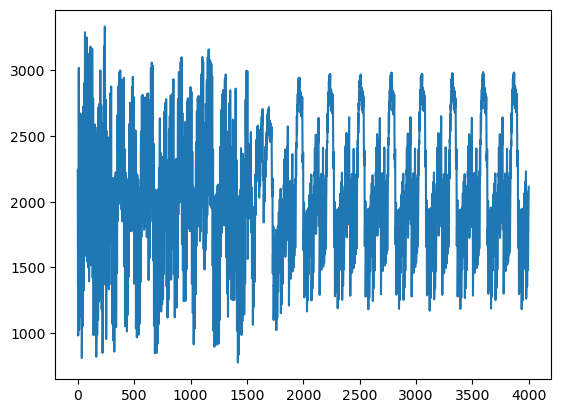

In [6]:
import matplotlib.pyplot as plt

plt.plot(trace1[:4000])

In [7]:
from tqdm import tqdm
import numpy as np
np.random.seed(0)

N = 1
bit = 16

def store16(x):
    return [x & 0xFF, (x >> 8) & 0xFF]

for i in range(N):
    a = np.random.randint(0, 1 << bit)
    b = np.random.randint(0, 1 << bit)
    c = np.random.randint(0, 1 << bit)
    d = np.random.randint(0, 1 << bit)

    data = []
    data += store16(a)
    data += store16(b)
    data += store16(c)
    data += store16(d)

    msg = bytearray(data)    
    scope.arm()
    target.simpleserial_write('p', msg)
    scope.capture()
    res = target.simpleserial_read('r', 4)
    trace = scope.get_last_trace(as_int=True) # int16

In [8]:
expected = smuad(a, b, c, d)
actual = int.from_bytes(res, byteorder="little", signed=True)

print("a, b, c, d:", a, b, c, d)
print("expected:", expected)
print("actual:  ", actual)
print("match:   ", expected == actual)

a, b, c, d: 2732 43567 42613 52416
expected: 225607644
actual:   225607644
match:    True


In [9]:
from tqdm import tqdm
import numpy as np
np.random.seed(0)

save_dir = "trace_smuad_profile_bd0/"

N = 100000
bit = 16

def store16(x):
    return [x & 0xFF, (x >> 8) & 0xFF]

for i in tqdm(range(N)):
    a = np.random.randint(0, 1 << bit)
    b = 0
    #b = np.random.randint(0, 1 << bit)
    c = np.random.randint(0, 1 << bit)
    #d = np.random.randint(0, 1 << bit)
    d = 0

    data = []
    data += store16(a)
    data += store16(b)
    data += store16(c)
    data += store16(d)

    msg = bytearray(data)    
    scope.arm()
    target.simpleserial_write('p', msg)
    scope.capture()
    res = target.simpleserial_read('r', 4)
    trace = scope.get_last_trace(as_int=True) # int16

    expected = smuad(a, b, c, d)
    actual = int.from_bytes(res, byteorder="little", signed=True)
    assert(expected == actual)

    np.savez(save_dir + f"sample_{i:08}.npz", 
             trace=trace, 
             data=np.concatenate([res, msg]),
            )
    

100%|███████████████████████████████████████████████████████| 100000/100000 [44:33<00:00, 37.41it/s]


In [10]:
from tqdm import tqdm
import numpy as np
np.random.seed(0)

save_dir = "trace_smuad_profile_bd_non0/"

N = 100000
bit = 16

def store16(x):
    return [x & 0xFF, (x >> 8) & 0xFF]

for i in tqdm(range(N)):
    a = np.random.randint(0, 1 << bit)
    b = np.random.randint(0, 1 << bit)
    c = np.random.randint(0, 1 << bit)
    d = np.random.randint(0, 1 << bit)

    data = []
    data += store16(a)
    data += store16(b)
    data += store16(c)
    data += store16(d)

    msg = bytearray(data)    
    scope.arm()
    target.simpleserial_write('p', msg)
    scope.capture()
    res = target.simpleserial_read('r', 4)
    trace = scope.get_last_trace(as_int=True) # int16

    expected = smuad(a, b, c, d)
    actual = int.from_bytes(res, byteorder="little", signed=True)
    assert(expected == actual)

    np.savez(save_dir + f"sample_{i:08}.npz", 
             trace=trace, 
             data=np.concatenate([res, msg]),
            )
    

100%|███████████████████████████████████████████████████████| 100000/100000 [45:02<00:00, 37.01it/s]


In [9]:


_b = np.arange(1 << 16, dtype=np.uint16).view(np.uint8).reshape(-1, 2)
HW16 = np.unpackbits(_b, axis=1).sum(axis=1).astype(np.uint8)

def hw_u16(x):
    return HW16[(x.astype(np.int64) & 0xFFFF).astype(np.uint16)].astype(np.float32)


def hw_i32(x):
    x = x.astype(np.int64) & 0xFFFFFFFF
    return HW16[(x & 0xFFFF).astype(np.uint16)].astype(np.float32) + \
           HW16[((x>>16)&0xFFFF).astype(np.uint16)].astype(np.float32)


(75.0, 160.0)

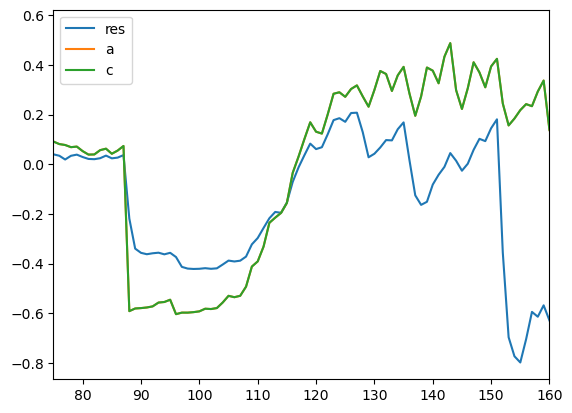

In [54]:
import matplotlib.pyplot as plt
from scaueclib import OnlineCPA
from tqdm import tqdm
import numpy as np


trace_dir = "trace_smuad_profile_bd0/"
#trace_dir = "trace_smuad_profile_bd_non0/"

N = 10000

SAMPLES = 1000
vec_res = OnlineCPA(SAMPLES)
vec_a = OnlineCPA(SAMPLES)
vec_c = OnlineCPA(SAMPLES)

for i in range(N):
    d = np.load(trace_dir + f"sample_{i:08}.npz")
    trace = d["trace"][:SAMPLES]
    meta_data = d["data"]

    res_bytes = meta_data[:4]
    res = int.from_bytes(res_bytes, byteorder="little", signed=True)

    a = get_int16(meta_data, 4)
    b = get_int16(meta_data, 6)
    c = get_int16(meta_data, 8)
    d = get_int16(meta_data, 10)
    e = smuad(a, b, c, d)
    assert(e == res)

    res = np.int32(res)
    label = hw_i32(res)
    vec_res.update(trace, label)

    res = np.int32(a)
    label = hw_i32(res)
    vec_a.update(trace, label)

    res = np.int32(a)
    label = hw_i32(res)
    vec_c.update(trace, label)


plt.plot(vec_res.get_pearson_corr(), label="res")
plt.plot(vec_a.get_pearson_corr(), label="a")
plt.plot(vec_c.get_pearson_corr(), label="c")
plt.legend()

plt.xlim(75, 160)

(75.0, 140.0)

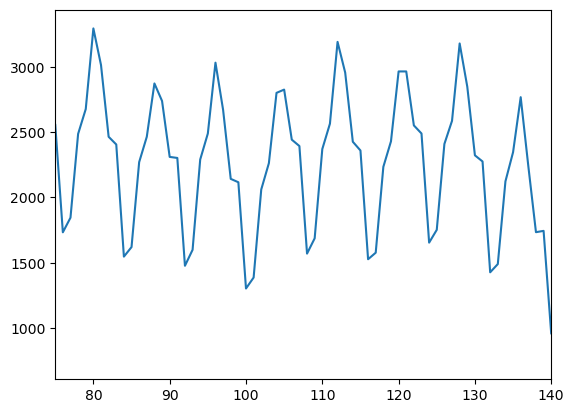

In [40]:
import matplotlib.pyplot as plt

plt.plot(trace[:200])
plt.xlim(75, 140)

In [52]:


N = 20000

SAMPLES = 1000

mean_0 = np.zeros(SAMPLES)
m2_0 = np.zeros(SAMPLES)

mean_1 = np.zeros(SAMPLES)
m2_1 = np.zeros(SAMPLES)


for i in tqdm(range(N)):
    inv_n = 1.0 / (i+1)

    d = np.load("trace_smuad_profile_bd0/" + f"sample_{i:08}.npz")
    trace = d["trace"][:SAMPLES]

    delta = (trace - mean_0)
    mean_0 += inv_n * delta
    m2_0 += delta * (trace - mean_0)
    
    d = np.load("trace_smuad_profile_bd_non0/" + f"sample_{i:08}.npz")
    trace = d["trace"][:SAMPLES]

    delta = (trace - mean_1)
    mean_1 += inv_n * delta
    m2_1 += delta * (trace - mean_1)



100%|█████████████████████████████████████████████████████████████| 20000/20000 [00:07<00:00, 2523.59it/s]


(75.0, 160.0)

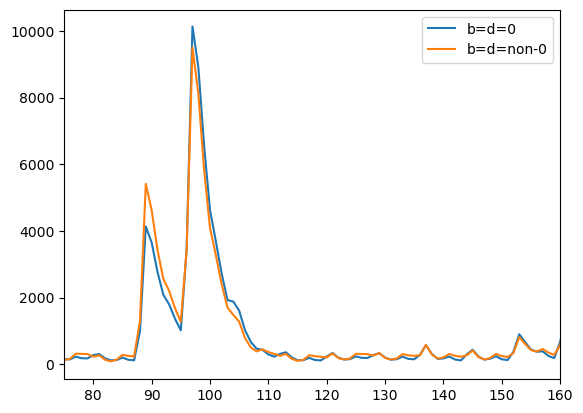

In [53]:
var_0 = m2_0 / N
var_1 = m2_1 / N

plt.plot(var_0, label="b=d=0")
plt.plot(var_1, label="b=d=non-0")

plt.legend()
plt.xlim(75, 160)

In [62]:
period = 8
exe_start = 88
exe_end = exe_start + period

N = 20000

mean_0_single = 0.0
m2_0_single = 0.0

mean_1_single = 0.0
m2_1_single = 0.0

for i in tqdm(range(N)):
    inv_n = 1.0 / (i+1)

    d = np.load("trace_smuad_profile_bd0/" + f"sample_{i:08}.npz")
    trace = d["trace"][exe_start : exe_end]
    trace = np.sum(trace)
    
    delta = (trace - mean_0_single)
    mean_0_single += inv_n * delta
    m2_0_single += delta * (trace - mean_0_single)
    
    d = np.load("trace_smuad_profile_bd_non0/" + f"sample_{i:08}.npz")
    trace = d["trace"][exe_start : exe_end]
    trace = np.sum(trace)

    delta = (trace - mean_1_single)
    mean_1_single += inv_n * delta
    m2_1_single += delta * (trace - mean_1_single)



100%|█████████████████████████████████████████████████████████████| 20000/20000 [00:06<00:00, 2964.33it/s]


In [65]:
var_0_single = m2_0_single / N
var_1_single = m2_1_single / N

print(var_0_single, var_1_single)
print(var_0_single - var_1_single)

124531.64296719652 156436.2836694383
-31904.640702241784


In [70]:
lane_var = abs(var_0_single - var_1_single)

sgm = 20
snr1 = (lane_var + sgm**2) / sgm**2
snr2 = (lane_var + lane_var + sgm**2) / (lane_var + sgm**2)

print("Lave var:", np.sqrt(lane_var))
print(snr1, snr2)
print(snr1 / snr2)


Lave var: 178.61870199461697
80.76160175560446 1.9876178780724765
40.632358285046365
